# Overcooked LLM Wrapper Demonstration

This notebook demonstrates how the `OvercookedLLMWrapper` works with mock LLM responses.
We'll see:
1. Environment setup and visualization
2. Observation encoding (grid → text)
3. Mock LLM responses (communication + plans)
4. Action execution (plans → discrete actions)
5. Sequential agent processing with conversation history


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jaxmarl import make
from jaxmarl.viz.overcooked_v2_visualizer import OvercookedV2Visualizer
from jaxmarl.environments.overcooked_v2.common import Actions

from llm_trainer.overcooked_llm_wrapper import OvercookedLLMWrapper
from llm_trainer.observation_encoder import encode_state_for_agent
from llm_trainer.communication import format_agent_prompt, parse_llm_response, ActionPlan
from llm_trainer.action_executor import ActionExecutor

# Set random seed for reproducibility
key = jax.random.PRNGKey(42)

# Create environment
env = make(
    "overcooked_v2",
    layout="cramped_room",
    max_steps=400,
    agent_view_size=None,  # Full observability
    random_agent_positions=False,
)

print(f"Environment created: {env.width}x{env.height} grid")
print(f"Number of agents: {env.num_agents}")


Importing submoduled environments...
Submoduled environments not found. Skipping import.
Environment created: 5x4 grid
Number of agents: 2


## 1. Visualize Initial Environment State


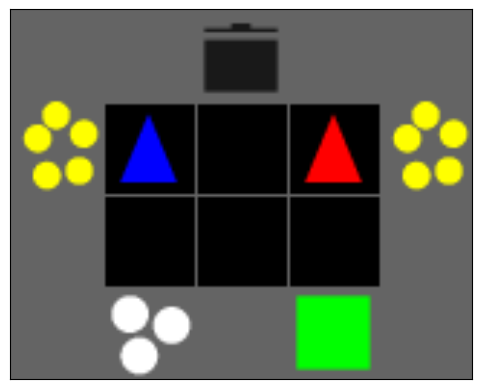

TypeError: Image data of dtype object cannot be converted to float

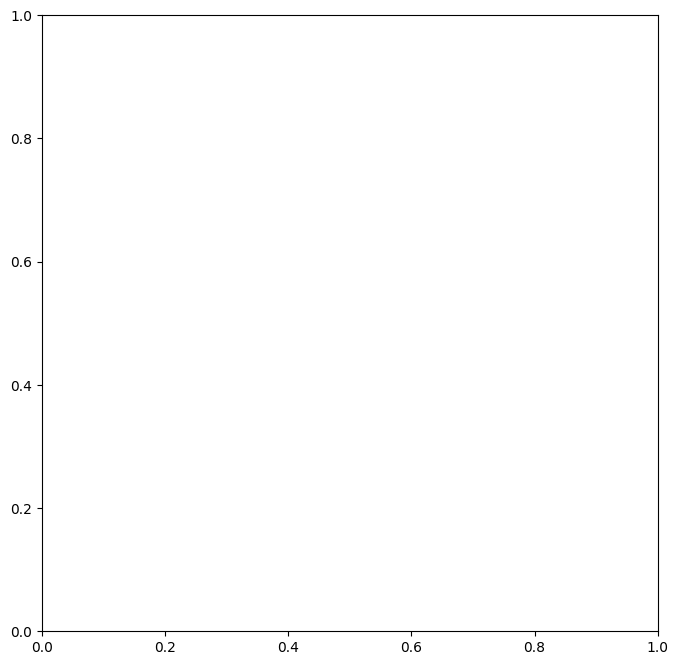

In [2]:
# Reset environment
key, reset_key = jax.random.split(key)
obs, state = env.reset(reset_key)

# Visualize initial state
viz = OvercookedV2Visualizer()
frame = viz.render(state)

plt.figure(figsize=(10, 8))
plt.imshow(frame)
plt.title("Initial Environment State")
plt.axis('off')
plt.show()

print(f"Agent 0 position: ({state.agents.pos.x[0]}, {state.agents.pos.y[0]})")
print(f"Agent 1 position: ({state.agents.pos.x[1]}, {state.agents.pos.y[1]})")
print(f"Current recipe: {state.recipe}")


## 2. Show Observation Encoding (Grid → Text)


In [3]:
# Encode observations for both agents
obs_text_agent0 = encode_state_for_agent(state, 0, env)
obs_text_agent1 = encode_state_for_agent(state, 1, env)

print("=" * 60)
print("AGENT 0 OBSERVATION (Text)")
print("=" * 60)
print(obs_text_agent0)

print("\n" + "=" * 60)
print("AGENT 1 OBSERVATION (Text)")
print("=" * 60)
print(obs_text_agent1)


AGENT 0 OBSERVATION (Text)
Agent at position (3, 1), facing up
Holding: nothing
Current recipe requires: 3x ingredient0
No visible objects (only walls or empty space)

AGENT 1 OBSERVATION (Text)
Agent at position (1, 1), facing up
Holding: nothing
Current recipe requires: 3x ingredient0
No visible objects (only walls or empty space)


## 3. Mock LLM Function

This simulates what an LLM would return. In real training, this would be an actual LLM call.


In [5]:
# Use a global step counter to track progress
_mock_step_counter = {"step": 0, "calls_this_step": 0}

def reset_mock_llm():
    """Reset the mock LLM step counter (call this when starting a new episode)."""
    global _mock_step_counter
    _mock_step_counter = {"step": 0, "calls_this_step": 0}

def mock_llm_generate(prompt: list) -> str:
    """Mock LLM that returns hardcoded responses based on prompt content and step."""
    global _mock_step_counter
    
    prompt_text = "\n".join([msg.get("content", "") for msg in prompt])
    
    # Determine which agent this is
    is_agent_0 = "agent_0" in prompt_text or "Agent 0" in prompt_text
    is_agent_1 = "agent_1" in prompt_text or "Agent 1" in prompt_text
    
    # Check conversation history for context
    has_conversation = "Conversation History" in prompt_text or "conversation history" in prompt_text.lower()
    
    # Extract conversation messages if present
    conversation_messages = []
    if has_conversation:
        import re
        # Extract messages from conversation history
        history_matches = re.findall(r'\[(agent_\d) to (agent_\d)\]: ([^\n]+)', prompt_text)
        conversation_messages = history_matches
    
    # Step 0: Initial planning (no conversation history)
    if not has_conversation:
        _mock_step_counter["step"] = 0
        _mock_step_counter["calls_this_step"] = 0
        if is_agent_0:
            return """<communication>
  <to_agent>agent_1</to_agent>
  <message>I'll get the onions and put them in the pot. Can you get a plate ready?</message>
</communication>
<plan>
  <action>pickup_ingredient</action>
  <ingredients>[0]</ingredients>
  <description>Pick up onion from ingredient pile</description>
</plan>"""
        elif is_agent_1:
            return """<communication>
  <to_agent>agent_0</to_agent>
  <message>Sure! I'll get a plate and wait for the soup to be ready.</message>
</communication>
<plan>
  <action>pickup_plate</action>
  <description>Get a plate from the plate pile</description>
</plan>"""
    
    # Step 1+: Based on conversation history and agent
    # Increment step only when both agents have been called (every 2 calls)
    _mock_step_counter["calls_this_step"] += 1
    if _mock_step_counter["calls_this_step"] >= 2:
        _mock_step_counter["step"] += 1
        _mock_step_counter["calls_this_step"] = 0
    step = _mock_step_counter["step"]
    
    # Check what was discussed in conversation
    last_message = conversation_messages[-1][2] if conversation_messages else ""
    
    if is_agent_0:
        # Agent 0's responses based on step and conversation
        if step <= 2 or "onion" in last_message.lower() or "get" in last_message.lower():
            return """<communication>
  <to_agent>agent_1</to_agent>
  <message>Got the onion! Moving to the pot now.</message>
</communication>
<plan>
  <action>cook_dish</action>
  <ingredients>[0]</ingredients>
  <description>Put onion in pot and cook</description>
</plan>"""
        elif "pot" in last_message.lower() or "cook" in last_message.lower():
            return """<communication>
  <to_agent>agent_1</to_agent>
  <message>Cooking the soup now. It should be ready soon!</message>
</communication>
<plan>
  <action>wait</action>
  <description>Wait for cooking to complete</description>
</plan>"""
        else:
            # Continue with useful action
            return """<communication>
  <to_agent>agent_1</to_agent>
  <message>Working on the recipe. How are you doing with the plate?</message>
</communication>
<plan>
  <action>cook_dish</action>
  <ingredients>[0]</ingredients>
  <description>Continue cooking process</description>
</plan>"""
    
    elif is_agent_1:
        # Agent 1's responses based on step and conversation
        if step <= 2 or "plate" in last_message.lower() or "ready" in last_message.lower():
            return """<communication>
  <to_agent>agent_0</to_agent>
  <message>I have the plate ready. Let me know when the soup is done!</message>
</communication>
<plan>
  <action>wait</action>
  <description>Wait for soup to be ready</description>
</plan>"""
        elif "done" in last_message.lower() or "ready" in last_message.lower():
            return """<communication>
  <to_agent>agent_0</to_agent>
  <message>Great! I'll pick up the soup and deliver it.</message>
</communication>
<plan>
  <action>deliver_dish</action>
  <description>Pick up cooked dish and deliver to goal</description>
</plan>"""
        else:
            # Continue with useful action
            return """<communication>
  <to_agent>agent_0</to_agent>
  <message>Standing by with the plate. Ready when you are!</message>
</communication>
<plan>
  <action>wait</action>
  <description>Wait for dish to be ready</description>
</plan>"""
    
    # Fallback (shouldn't reach here often)
    if is_agent_0:
        return """<communication>
  <to_agent>agent_1</to_agent>
  <message>Continuing with cooking.</message>
</communication>
<plan>
  <action>cook_dish</action>
  <ingredients>[0]</ingredients>
  <description>Continue cooking</description>
</plan>"""
    else:
        return """<communication>
  <to_agent>agent_0</to_agent>
  <message>Ready to help when needed.</message>
</communication>
<plan>
  <action>wait</action>
  <description>Wait for next task</description>
</plan>"""

print("Mock LLM function created with improved state tracking!")


Mock LLM function created with improved state tracking!


## 4. Create Wrapper and Run One Step


In [6]:
# Create wrapper with mock LLM
wrapper = OvercookedLLMWrapper(env, mock_llm_generate)

# Run one step
conversation_history = []
obs_dict = {"agent_0": obs["agent_0"], "agent_1": obs["agent_1"]}

print("Running one step with LLM wrapper...")
print("-" * 60)

# Step with LLM
actions, updated_history, llm_responses = wrapper.step_with_llm(
    obs_dict, state, conversation_history
)

print(f"\nActions generated: {actions}")
print(f"\nConversation history length: {len(updated_history)}")
print(f"\nLLM Responses:")
for agent_id, response in llm_responses.items():
    print(f"\n{agent_id}:")
    if response.communication:
        print(f"  Communication: {response.communication.message}")
    if response.plan:
        print(f"  Plan: {response.plan.action} - {response.plan.description}")


Running one step with LLM wrapper...
------------------------------------------------------------

Actions generated: {'agent_0': 0, 'agent_1': 0}

Conversation history length: 2

LLM Responses:

agent_0:
  Communication: I'll get the onions and put them in the pot. Can you get a plate ready?
  Plan: pickup_ingredient - Pick up onion from ingredient pile

agent_1:
  Communication: Got the onion! Moving to the pot now.
  Plan: cook_dish - Put onion in pot and cook


## 5. Show Detailed Step-by-Step Process


In [12]:
# Reset for detailed demonstration
reset_mock_llm()  # Reset the mock LLM step counter
key, reset_key = jax.random.split(key)
obs, state = env.reset(reset_key)
conversation_history = []

print("=" * 60)
print("DETAILED STEP-BY-STEP DEMONSTRATION")
print("=" * 60)

for step in range(3):
    print(f"\n{'='*60}")
    print(f"STEP {step + 1}")
    print(f"{'='*60}")
    
    # Get observations
    obs_text_agent0 = encode_state_for_agent(state, 0, env)
    obs_text_agent1 = encode_state_for_agent(state, 1, env)
    
    # Format prompts
    prompt_agent0 = format_agent_prompt(obs_text_agent0, 0, conversation_history)
    
    print(f"\n[Agent 0] Prompt (first 200 chars):")
    print("\n".join([f"{msg['role']}: {msg['content'][:200]}..." for msg in prompt_agent0[:2]]))
    
    # Get LLM response for agent 0
    response_text_agent0 = mock_llm_generate(prompt_agent0)
    llm_response_agent0 = parse_llm_response(response_text_agent0, "agent_0", "agent_1")
    
    print(f"\n[Agent 0] LLM Response:")
    print(response_text_agent0)
    
    if llm_response_agent0.communication:
        conversation_history.append(llm_response_agent0.communication)
        print(f"\n[Agent 0] Communication: {llm_response_agent0.communication.message}")
    
    if llm_response_agent0.plan:
        print(f"[Agent 0] Plan: {llm_response_agent0.plan.action} - {llm_response_agent0.plan.description}")
    
    # Now agent 1 sees updated history
    prompt_agent1 = format_agent_prompt(obs_text_agent1, 1, conversation_history)
    
    print(f"\n[Agent 1] Prompt (includes Agent 0's message):")
    print(f"Conversation history: {len(conversation_history)} messages")
    
    # Get LLM response for agent 1
    response_text_agent1 = mock_llm_generate(prompt_agent1)
    llm_response_agent1 = parse_llm_response(response_text_agent1, "agent_1", "agent_0")
    
    print(f"\n[Agent 1] LLM Response:")
    print(response_text_agent1)
    
    if llm_response_agent1.communication:
        conversation_history.append(llm_response_agent1.communication)
        print(f"\n[Agent 1] Communication: {llm_response_agent1.communication.message}")
    
    if llm_response_agent1.plan:
        print(f"[Agent 1] Plan: {llm_response_agent1.plan.action} - {llm_response_agent1.plan.description}")
    
    # Execute plans
    # Execute plans
    executor = ActionExecutor(env)

    # Initialize action buffers
    action_buffers = {"agent_0": None, "agent_1": None}

    # Get next action for each agent
    if llm_response_agent0.plan:
        action_agent0, action_buffers["agent_0"] = executor.execute_plan_step(
            llm_response_agent0.plan, state, 0, action_buffers["agent_0"]
        )
    else:
        action_agent0 = Actions.stay

    if llm_response_agent1.plan:
        action_agent1, action_buffers["agent_1"] = executor.execute_plan_step(
            llm_response_agent1.plan, state, 1, action_buffers["agent_1"]
        )
    else:
        action_agent1 = Actions.stay

    print(f"\n[Agent 0] Executing action: {action_agent0}")
    print(f"[Agent 1] Executing action: {action_agent1}")

    # Step environment
    actions_dict = {"agent_0": jnp.array(int(action_agent0)), "agent_1": jnp.array(int(action_agent1))}
    key, step_key = jax.random.split(key)
    obs, state, rewards, dones, info = env.step(step_key, state, actions_dict)
    
    print(f"\nRewards: {rewards}")
    print(f"Dones: {dones}")


DETAILED STEP-BY-STEP DEMONSTRATION

STEP 1

[Agent 0] Prompt (first 200 chars):
system: You are an agent in a cooperative cooking game called Overcooked. You work with another agent to cook dishes and deliver them to the goal.

Your task:
1. Observe your local environment
2. Communicate ...
user: You are agent_0. The other agent is agent_1.

Your Observation:
Agent at position (3, 1), facing up
Holding: nothing
Current recipe requires: 3x ingredient0
No visible objects (only walls or empty spa...

[Agent 0] LLM Response:
<communication>
  <to_agent>agent_1</to_agent>
  <message>I'll get the onions and put them in the pot. Can you get a plate ready?</message>
</communication>
<plan>
  <action>pickup_ingredient</action>
  <ingredients>[0]</ingredients>
  <description>Pick up onion from ingredient pile</description>
</plan>

[Agent 0] Communication: I'll get the onions and put them in the pot. Can you get a plate ready?
[Agent 0] Plan: pickup_ingredient - Pick up onion from ingredient pi

## 6. Visualize Action Execution


Running 5 steps with visualization...


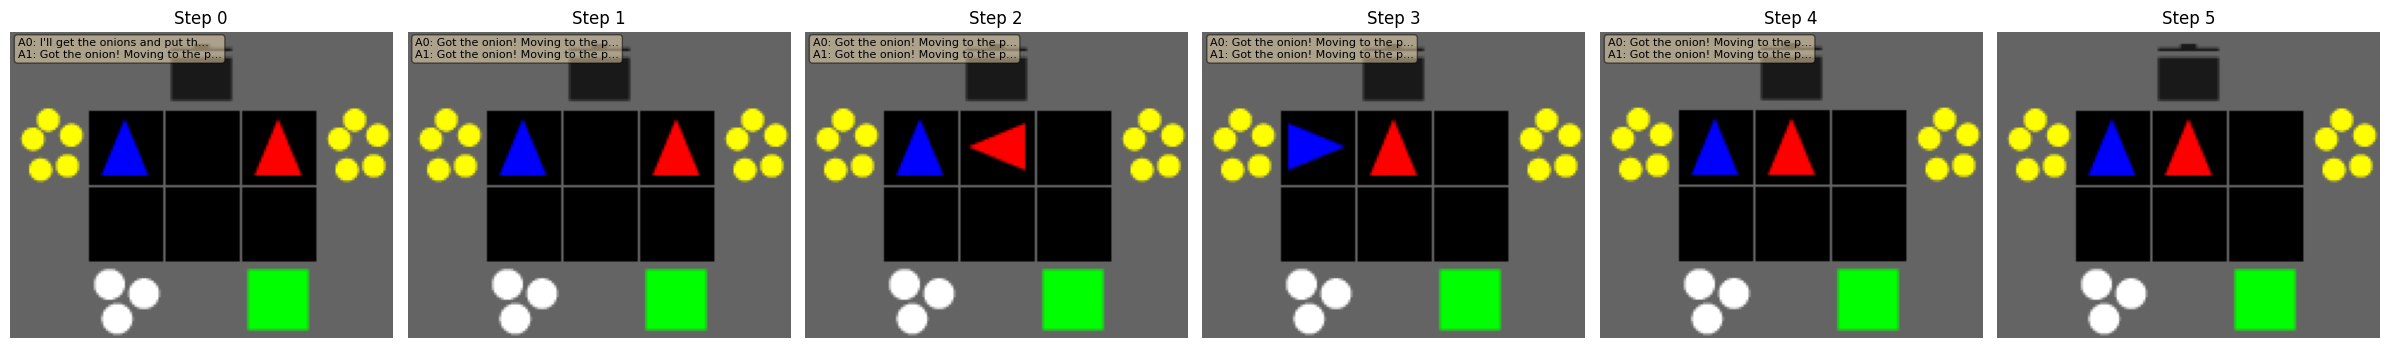


CONVERSATION SUMMARY

Step 0:
  Agent 0 → Agent 1: I'll get the onions and put them in the pot. Can you get a plate ready?
  Agent 1 → Agent 0: Got the onion! Moving to the pot now.

Step 1:
  Agent 0 → Agent 1: Got the onion! Moving to the pot now.
  Agent 1 → Agent 0: Got the onion! Moving to the pot now.

Step 2:
  Agent 0 → Agent 1: Got the onion! Moving to the pot now.
  Agent 1 → Agent 0: Got the onion! Moving to the pot now.

Step 3:
  Agent 0 → Agent 1: Got the onion! Moving to the pot now.
  Agent 1 → Agent 0: Got the onion! Moving to the pot now.

Step 4:
  Agent 0 → Agent 1: Got the onion! Moving to the pot now.
  Agent 1 → Agent 0: Got the onion! Moving to the pot now.


: 

In [ ]:
# Reset and run a few steps with visualization
reset_mock_llm()  # Reset the mock LLM step counter
key, reset_key = jax.random.split(key)
obs, state = env.reset(reset_key)
conversation_history = []

states_sequence = [state]
actions_sequence = []
conversations_sequence = []

print("Running 5 steps with visualization...")

for step in range(5):
    # Use wrapper to get actions
    obs_dict = {"agent_0": obs["agent_0"], "agent_1": obs["agent_1"]}
    actions, updated_history, llm_responses = wrapper.step_with_llm(
        obs_dict, state, conversation_history
    )
    
    conversations_sequence.append({
        "step": step,
        "agent_0_msg": llm_responses["agent_0"].communication.message if llm_responses["agent_0"].communication else None,
        "agent_1_msg": llm_responses["agent_1"].communication.message if llm_responses["agent_1"].communication else None,
    })
    
    # Step environment
    key, step_key = jax.random.split(key)
    obs, state, rewards, dones, info = env.step(step_key, state, actions)
    
    states_sequence.append(state)
    actions_sequence.append(actions)
    conversation_history = updated_history
    
    if dones["__all__"]:
        break

# Visualize sequence
from jax import tree_util

def stack_states(state_list):
    """Stack a list of states into a batched state for vmap"""
    return tree_util.tree_map(lambda *xs: jnp.stack(xs), *state_list)

batched_state = stack_states(states_sequence)
frame_seq = viz.render_sequence(batched_state, agent_view_size=None)

# Display frames
fig, axes = plt.subplots(1, len(frame_seq), figsize=(4*len(frame_seq), 4))
if len(frame_seq) == 1:
    axes = [axes]

for i, (frame, ax) in enumerate(zip(frame_seq, axes)):
    ax.imshow(frame)
    ax.set_title(f"Step {i}")
    ax.axis('off')
    
    # Add conversation info
    if i < len(conversations_sequence):
        conv = conversations_sequence[i]
        info_text = f"A0: {conv['agent_0_msg'][:30] if conv['agent_0_msg'] else 'None'}...\n"
        info_text += f"A1: {conv['agent_1_msg'][:30] if conv['agent_1_msg'] else 'None'}..."
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, 
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print conversation summary
print("\n" + "=" * 60)
print("CONVERSATION SUMMARY")
print("=" * 60)
for conv in conversations_sequence:
    print(f"\nStep {conv['step']}:")
    if conv['agent_0_msg']:
        print(f"  Agent 0 → Agent 1: {conv['agent_0_msg']}")
    if conv['agent_1_msg']:
        print(f"  Agent 1 → Agent 0: {conv['agent_1_msg']}")


## 7. Show Action Executor Details


In [9]:
# Demonstrate action executor with different plans
executor = ActionExecutor(env)

# Reset to known state
key, reset_key = jax.random.split(key)
obs, state = env.reset(reset_key)

print("Testing Action Executor with different plans:")
print("=" * 60)

# Test 1: Pickup ingredient
plan1 = ActionPlan(
    action="pickup_ingredient",
    ingredients=[0],  # Onion
    description="Pick up onion"
)
action1 = executor.execute_plan(plan1, 0, state)
print(f"\nPlan: {plan1.action} (ingredients: {plan1.ingredients})")
print(f"Executed action: {action1}")

# Test 2: Cook dish
plan2 = ActionPlan(
    action="cook_dish",
    ingredients=[0],
    description="Cook onion soup"
)
action2 = executor.execute_plan(plan2, 0, state)
print(f"\nPlan: {plan2.action} (ingredients: {plan2.ingredients})")
print(f"Executed action: {action2}")

# Test 3: Pickup plate
plan3 = ActionPlan(
    action="pickup_plate",
    description="Get a plate"
)
action3 = executor.execute_plan(plan3, 1, state)
print(f"\nPlan: {plan3.action}")
print(f"Executed action: {action3}")

# Test 4: Deliver dish
plan4 = ActionPlan(
    action="deliver_dish",
    description="Deliver completed dish"
)
action4 = executor.execute_plan(plan4, 1, state)
print(f"\nPlan: {plan4.action}")
print(f"Executed action: {action4}")


Testing Action Executor with different plans:


AttributeError: 'int' object has no attribute 'agents'

## Summary

This demonstration shows:

1. **Observation Encoding**: Grid observations are converted to text descriptions
2. **Sequential Processing**: Agent 0 sees its observation + history → generates response → Agent 1 sees its observation + updated history
3. **Communication**: Agents exchange messages in XML format
4. **Planning**: LLM generates high-level action plans
5. **Execution**: Action executor translates plans to discrete environment actions
6. **Visualization**: Environment state and agent movements are visualized

The key insight is that **agents only see their own observations**, making communication meaningful and necessary for coordination.
